# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024160118      # <-- your full roll number
NAME = "Ayush Kamboj"          # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160118   Name: Ayush Kamboj   Fingerprint: 678E557A   Tickets: 15

Ticket_ID                                                                       Ticket_Text
      T01               Server crashes while opening while uploading the file. Please help.
      T02                                                       The file is 95.5% uploaded.
      T03                 The printer keeps asking for login. It works on another computer.
      T04             I can't open the Wi-Fi during the lab. The same problem occurs again.
      T05                  The laptop was working yesterday. The same problem occurs again.
      T06                        The VPN is showing an error. It works on another computer.
      T07                                                Dr. Rao's lab PC (No. 14) is down.
      T08 Email keeps asking for login when connected to campus Wi-Fi. It worked yesterday.
      T09            VPN was working yesterday after resetting my password. This is urge

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
# Your code
# Q1: Preprocessing pipeline

import pandas as pd

rows = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])

    rows.append({
        "Ticket_ID": row["Ticket_ID"],
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique_Tokens": len(set(result["tokens"])),
        "Final_Tokens": len(result["final"])
    })

q1_table = pd.DataFrame(rows)

total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation": q1_table["Punctuation"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique_Tokens": q1_table["Unique_Tokens"].sum(),
    "Final_Tokens": q1_table["Final_Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

display(q1_table)

# Display actual tokens for the first ticket
sample = process_ticket(df.iloc[0]["Ticket_Text"])

print("\nSelected Ticket:", df.iloc[0]["Ticket_ID"])
print("Text:", df.iloc[0]["Ticket_Text"])
print("\nTokens:", sample["tokens"])
print("Punctuation:", sample["punct"])
print("Stopwords:", sample["stops"])
print("Final Tokens:", sample["final"])

,Ticket_ID,Sentences,Tokens,Punctuation,Stopwords,Unique_Tokens,Final_Tokens
0,T01,2,12,2,3,10,7
1,T02,1,7,2,2,7,3
2,T03,2,13,2,4,12,7
3,T04,2,16,2,7,13,7
4,T05,2,12,2,5,10,5
5,T06,2,13,2,5,12,6
6,T07,2,13,4,3,12,6
7,T08,2,15,2,4,14,9
8,T09,2,13,2,5,12,6
9,T10,2,7,2,3,6,2



Selected Ticket: T01
Text: Server crashes while opening while uploading the file. Please help.

Tokens: ['server', 'crashes', 'while', 'opening', 'while', 'uploading', 'the', 'file', '.', 'please', 'help', '.']
Punctuation: ['.', '.']
Stopwords: ['while', 'while', 'the']
Final Tokens: ['server', 'crashes', 'opening', 'uploading', 'file', 'please', 'help']


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

Your answer:The final tokens that are not real words include ca, n't, and 's. They come from word_tokenize(), which splits contractions into separate tokens. For example, can't → ca + n't and was + 's can produce contraction fragments. These fragments are punctuation/contraction parts rather than normal English words.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [6]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Your code
# Q2: Regular expressions

import re

# 1. Words longer than 5 letters
long_words_pattern = r"\b[A-Za-z]{6,}\b"

# 2. Numbers including decimals, percentages and versions
numbers_pattern = r"\b\d+(?:\.\d+)+%?|\b\d+%?\b"

# 3. Capitalized words
capitalized_pattern = r"\b[A-Z][a-zA-Z]*\b"

# 4. Words starting with a vowel
vowel_pattern = r"\b[AEIOUaeiou][A-Za-z]*\b"

# Extract from TEST_LINES
for i, line in enumerate(TEST_LINES, 1):
    print(f"\nTEST LINE {i}:")
    print("Long words:", re.findall(long_words_pattern, line))
    print("Numbers:", re.findall(numbers_pattern, line))
    print("Capitalized words:", re.findall(capitalized_pattern, line))
    print("Vowel words:", re.findall(vowel_pattern, line))


# Replacement patterns
email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"

url_pattern = r"https?://[^\s]+|www\.[^\s]+"

phone_pattern = r"(?<!\d)(?:\+91[\s-]?)?(?:\d{5}[\s-]?\d{5}|\d{4}[\s-]?\d{3}[\s-]?\d{4})(?!\d)"


def replace_patterns(text):
    text = re.sub(email_pattern, "<EMAIL>", text)
    text = re.sub(url_pattern, "<URL>", text)
    text = re.sub(phone_pattern, "<PHONE>", text)
    return text


print("\n\n--- REPLACED TEST LINES ---")

for line in TEST_LINES:
    print(replace_patterns(line))


print("\n--- REGEX EXTRACTION FROM TICKETS ---")

for _, row in df.iterrows():
    text = row["Ticket_Text"]

    print("\n", row["Ticket_ID"])
    print("Long words:", re.findall(long_words_pattern, text))
    print("Numbers:", re.findall(numbers_pattern, text))
    print("Capitalized:", re.findall(capitalized_pattern, text))
    print("Vowel words:", re.findall(vowel_pattern, text))
    print("Replaced:", replace_patterns(text))


TEST LINE 1:
Long words: ['helpdesk', 'thapar', 'thapar', 'thapar']
Numbers: []
Capitalized words: ['Mail']
Vowel words: ['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']

TEST LINE 2:
Long words: ['Version']
Numbers: ['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5%', '1', '250']
Capitalized words: ['Call', 'Version', 'Rs']
Vowel words: ['or', 'is']

TEST LINE 3:
Long words: []
Numbers: ['5.30']
Capitalized words: ['The']
Vowel words: ['of', 'art', 'isn', 'open', 'in', 'at']


--- REPLACED TEST LINES ---
Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>
Call <PHONE>, <PHONE> or <PHONE>. Version 2.0.1 is 95.5% done; fee Rs 1,250.
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.

--- REGEX EXTRACTION FROM TICKETS ---

 T01
Long words: ['Server', 'crashes', 'opening', 'uploading', 'Please']
Numbers: []
Capitalized: ['Server', 'Please']
Vowel words: ['opening', 'uploading']
Replaced: Server crashes while opening 

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

Your answer:4 capitalized words are capitalized only because they start a sentence: Mail, Call, Version, and The.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [7]:
# Your code
# Q3: Custom tokenizer

from nltk.tokenize import RegexpTokenizer

pattern = r"""
(?:https?://[^\s]+|www\.[^\s]+)                  # URLs
|(?:[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}) # Emails
|(?:\+91[\s-]?\d{5}[\s-]?\d{5})                 # +91 phone
|(?:\d{4}[\s-]?\d{3}[\s-]?\d{4})                # Indian phone
|(?:\d{5}[\s-]?\d{5})                            # 10 digit phone
|(?:\d+(?:\.\d+)+%?)                             # decimals/versions
|(?:[A-Za-z]+(?:'[A-Za-z]+)+)                     # contractions
|(?:[A-Za-z]+(?:-[A-Za-z]+)+)                     # hyphenated words
|(?:[A-Za-z]+)                                    # normal words
"""

tokenizer = RegexpTokenizer(pattern, flags=re.VERBOSE)


def my_tokenize(text):
    return tokenizer.tokenize(text)


print("--- TEST_LINES ---")

for line in TEST_LINES:
    print("\nOriginal:", line)
    print("word_tokenize:", word_tokenize(line))
    print("my_tokenize:", my_tokenize(line))


print("\n--- TICKETS ---")

different_tickets = 0

for _, row in df.iterrows():
    normal = word_tokenize(row["Ticket_Text"])
    custom = my_tokenize(row["Ticket_Text"])

    if normal != custom:
        different_tickets += 1

    print("\n", row["Ticket_ID"])
    print("word_tokenize:", normal)
    print("my_tokenize:", custom)

print("\nNumber of tickets tokenized differently:",
      different_tickets)

--- TEST_LINES ---

Original: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
word_tokenize: ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
my_tokenize: ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

Original: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
word_tokenize: ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']
my_tokenize: ['Call', '+91 98765 43210', '+91-98765-43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5%', 'done', 'fee', 'Rs']

Original: The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
word_tokenize: ['The'

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

Your answer:15 tickets are tokenized differently. This is because my_tokenize() is designed to preserve contractions, hyphenated words, decimals, versions, emails, URLs and phone numbers as single tokens, whereas word_tokenize() splits some of these into multiple tokens. For example, "can't" becomes ca and n't with word_tokenize(), but remains can't with my_tokenize().

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [8]:
# Your code
# Q4: Stemming and Lemmatization

from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

porter = PorterStemmer()
lancaster = LancasterStemmer()

# Chosen after observing words in the dataset such as:
# working, uploading, asking, running, syncing
regex_stemmer = RegexpStemmer(r"ing$", min=5)

lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


# Unique final tokens
final_tokens = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    final_tokens.extend(result["final"])

unique_tokens = sorted(set(final_tokens))


pos_results = pos_tag(unique_tokens)


rows = []

for word, tag in pos_results:
    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regex_result = regex_stemmer.stem(word)

    wn_pos = get_wordnet_pos(tag)
    lemma_result = lemmatizer.lemmatize(word, pos=wn_pos)

    if len({
        porter_result,
        lancaster_result,
        regex_result,
        lemma_result
    }) > 1:

        rows.append({
            "Word": word,
            "POS": tag,
            "Porter": porter_result,
            "Lancaster": lancaster_result,
            "RegexStemmer": regex_result,
            "WordNet": lemma_result
        })

q4_table = pd.DataFrame(rows)

display(q4_table)

,Word,POS,Porter,Lancaster,RegexStemmer,WordNet
0,another,DT,anoth,anoth,another,another
1,campus,VB,campu,camp,campus,campus
2,changed,VBN,chang,chang,changed,change
3,computer,NN,comput,comput,computer,computer
4,connected,VBN,connect,connect,connected,connect
5,crashes,NNS,crash,crash,crashes,crash
6,error,NN,error,er,error,error
7,file,NN,file,fil,file,file
8,keeps,NNS,keep,keep,keeps,keep
9,lms,NN,lm,lms,lms,lm


**Observe:** Give one over-stemming and one under-stemming example from your table.

Your answer:Over-stemming: A stemmer may reduce two different meaningful words to the same incorrect stem.
Example: words such as general and generate can sometimes be reduced too aggressively by a stemmer.

Under-stemming: Words having the same meaning may remain as different stems. For example, computer and computers may not always be reduced identically by every stemming method.


I chose the suffix ing because my dataset contains several words such as working, uploading, asking, running, and syncing. Removing ing helps reduce these words to simpler stems.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

,Corpus,Total Tokens,Unique Tokens,TTR
0,S1,180,88,0.488889
1,S2,149,83,0.557047
2,S3,86,57,0.662791
3,S4,86,53,0.616279



Top 10 words in S1:
[('.', 27), ('the', 14), ('is', 8), ('i', 4), ('yesterday', 4), ('while', 3), ('file', 3), ('it', 3), ('works', 3), ('another', 3)]

Top 10 words in S3:
[('yesterday', 4), ('file', 3), ('works', 3), ('another', 3), ("n't", 3), ('uploading', 2), ('please', 2), ('help', 2), ('printer', 2), ('keeps', 2)]


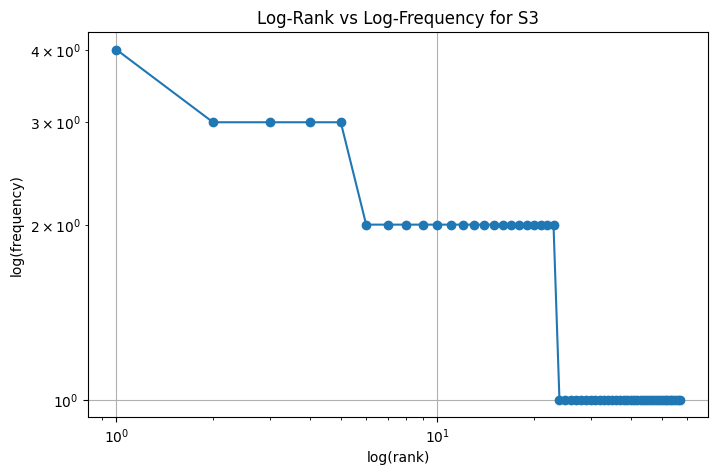


Top 5 bigrams in S1:
('.', 'the') : 7
('.', 'i') : 4
('the', 'file') : 3
('.', 'it') : 3
('yesterday', '.') : 3

Top 5 bigrams in S3:
('uploading', 'file') : 2
('file', 'please') : 2
('please', 'help') : 2
('keeps', 'asking') : 2
('asking', 'login') : 2


In [9]:
# Your code
# Q5: Corpus statistics

from collections import Counter
import math
import matplotlib.pyplot as plt


# S1: all tokens
S1 = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    S1.extend(result["tokens"])


# S2: tokens without punctuation
S2 = [
    token for token in S1
    if not is_punct(token)
]


# S3: final tokens
S3 = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    S3.extend(result["final"])


# S4: Porter stemmed S3
S4 = [porter.stem(token) for token in S3]


def corpus_statistics(tokens):
    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total > 0 else 0

    return total, unique, ttr


stats = pd.DataFrame([
    ["S1", *corpus_statistics(S1)],
    ["S2", *corpus_statistics(S2)],
    ["S3", *corpus_statistics(S3)],
    ["S4", *corpus_statistics(S4)]
], columns=["Corpus", "Total Tokens", "Unique Tokens", "TTR"])


display(stats)


# Top 10 words of S1 and S3
print("\nTop 10 words in S1:")
print(Counter(S1).most_common(10))

print("\nTop 10 words in S3:")
print(Counter(S3).most_common(10))


# Log-rank vs log-frequency plot for S3
freq = Counter(S3)

sorted_freq = sorted(
    freq.values(),
    reverse=True
)

ranks = range(1, len(sorted_freq) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(ranks, sorted_freq, marker="o")
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Log-Rank vs Log-Frequency for S3")
plt.grid(True)
plt.show()


# Top 5 bigrams
bigrams_S1 = Counter(
    zip(S1[:-1], S1[1:])
).most_common(5)

bigrams_S3 = Counter(
    zip(S3[:-1], S3[1:])
).most_common(5)

print("\nTop 5 bigrams in S1:")
for bg, count in bigrams_S1:
    print(bg, ":", count)

print("\nTop 5 bigrams in S3:")
for bg, count in bigrams_S3:
    print(bg, ":", count)

**Observe:** Why does TTR change from S1 to S4 in your data?

Your answer:TTR changes from S1 to S4 because S4 applies Porter stemming to the final tokens. Stemming converts different forms of the same word into a common stem, which reduces the number of unique tokens. Since TTR is calculated as unique tokens divided by total tokens, the TTR changes (usually decreases) after stemming.